# Data structures

Inputs and targets:
`train_x`: list of length `n_tasks`. Each entry is a `P`x`N0` array.
`train_y`: list of length `n_tasks`. Each entry is a `P`x1 array.
`test_x`: list of length `n_tasks`. Each entry is a `P_test`x`N0` array or `None`. If it is `None`, no test predictions are computed.
`test_y`: list of length `n_tasks`. Each entry is a `P`x1 array or `None`. If it is `None`, no test predictions are computed.

Predictions:
`training_predictions`: array of size `n_tasks`x`n_tasks`x`n_tasks`x`P`. Its i,j,k-th array is f_i(x_j,w_k). These indices are all time indices.
`test_predictions`: list of length `n_tasks`. Each entry is a `n_tasks`x`n_tasks`x`P_test` array. Its i,j-th array is f_i(x,w_j).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm, utils, theory, pickle, os, torch, torchvision
from numpy.linalg import inv as inv

%load_ext autoreload
%autoreload 2

P = 500
P_test = 500
n_tasks = 2
N0 = 1000
T = 0
sigma = 0.2
depth = 1

NUM_SEEDS = 3
fixed_w = False
teacher_speed = 1
input_rotation = 0
input_dist = 0

title_text = f'P={P},N0={N0},sigma={sigma},n_tasks={n_tasks},distance={input_dist:.3f}, \n ' +\
          f'teacher speed={teacher_speed},NUM_SEEDS={NUM_SEEDS},input rotation={input_rotation:.3f} \n' +\
    f'depth:{depth}'
if fixed_w:
    title_text += '\n ASSUMING FIXED W'

plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 6})

# lamb_values = 10 ** np.linspace(0, 4, 20)
# lamb_values = np.linspace(50, 2000, 30)
lamb_values = [0.1, 10000]

test_loss_all_tasks = np.zeros((len(lamb_values), NUM_SEEDS, n_tasks, n_tasks))  # only computes the test loss for each distribution AFTER all tasks are learnt
training_loss_all_tasks = np.zeros((len(lamb_values), NUM_SEEDS, n_tasks, n_tasks))  # lambda_index, seed_index, time_index, time_index

def prepare_student_teacher_data():
    train_x, test_x = utils.generate_rotating_inputs(P, P_test, N0, n_tasks, rotation=input_rotation, distance=input_dist)
    train_Y, test_Y = utils.get_teacher_labels(train_x, test_x, max_scaler=teacher_speed)
    # train_Y, test_Y = utils.get_linear_teacher_labels(train_x, test_x, max_scaler=teacher_speed)
    return train_x, test_x, train_Y, test_Y


# measure the test error ON THE LAST TASK from some special schemes
seed_avg_batch_test = np.zeros(NUM_SEEDS)
seed_avg_last_task_only_test = np.zeros(NUM_SEEDS)


for seed in range(NUM_SEEDS):
    np.random.seed(seed)

    train_x, test_x, train_Y, test_Y = prepare_student_teacher_data()

    seed_avg_batch_test[seed] = theory.one_task_loss(train_x=np.vstack(train_x), test_x=test_x[-1],
                                                     train_y=np.vstack(train_Y), test_y=test_Y[-1], depth=depth)
    seed_avg_last_task_only_test[seed] = theory.one_task_loss(train_x=train_x[-1], test_x=test_x[-1],
                                                              train_y=train_Y[-1], test_y=test_Y[-1], depth=depth)

    for sweep_ind in tqdm.trange(len(lamb_values)):

        lamb = lamb_values[sweep_ind]

        # training_predictions is a 4d tensor.
        # the first three indices (i,j,k) run from 1 to n_tasks and refer to f_i(x_j, w_k)
        # test_predictions is a list with length = number of test sets.
        training_predictions, test_predictions =\
            theory.compute_mean_predictions(seq_of_train_x=train_x, seq_of_train_y=train_Y, w_var=sigma**2, P_test=P_test,
                                            lambda_val=lamb, seq_of_test_x=test_x, fix_weights=fixed_w, disable_tqdm=True, depth=depth)

        test_loss_all_tasks[sweep_ind, seed] = utils.get_loss_matrix_single_task(test_predictions, test_Y)
        training_loss_all_tasks[sweep_ind, seed] = utils.get_loss_matrix_single_task(training_predictions, train_Y)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


100%|██████████| 2/2 [00:01<00:00,  1.76it/s]


In [3]:
print('dist between adjacent centers', np.linalg.norm(train_x[0].mean(0) - train_x[1].mean(0)))
print('dist between ends', np.linalg.norm(train_x[0].mean(0) - train_x[-1].mean(0)))
print('radius', input_dist)

dist between adjacent centers 2.022769488200208
dist between ends 2.022769488200208
radius 0


ValueError: too many values to unpack (expected 1)

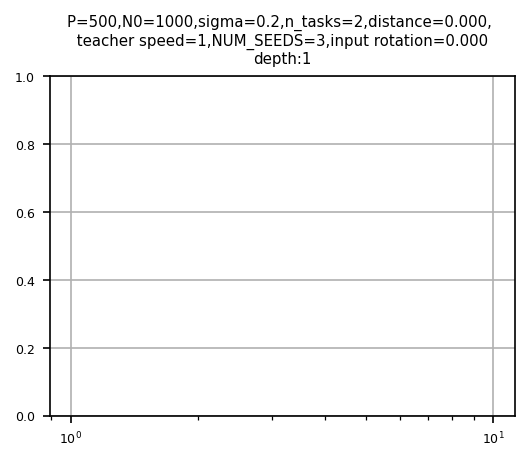

In [14]:
task_weights = np.ones(n_tasks) / n_tasks

def plot_data(data_mat, adjust, task):
    plt.figure(figsize=(4, 3))
    plt.xscale('log')

    plt.grid()
    plt.title(title_text)
    # assume a shape of sweed_ind x seed_ind x task_ind
    data_mat = data_mat.copy()
    if adjust:
        data_mat /= data_mat[0]
    assert task in ['mean', 'last', 'first']
    if task == 'mean':
        task_weights = np.ones(n_tasks) / n_tasks
    elif task == 'last':
        task_weights = np.zeros(n_tasks)
        task_weights[-1] = 1
    elif task == 'first':
        task_weights = np.zeros(n_tasks)
        task_weights[0] = 1
    plt.errorbar(lamb_values, data_mat.mean(1) @ task_weights, data_mat.var(1) @ task_weights)
    # plt.errorbar(lamb_values, data_mat.mean(1)[:< -1], data_mat.var(1).mean(-1))
    for seed in range(data_mat.shape[1]):
        plt.plot(lamb_values, data_mat[:, seed, :] @ task_weights, color='gray', alpha=0.5)
    plt.ylabel(task + ' test loss')


plot_data(test_loss_all_tasks, True, 'last')
plot_data(test_loss_all_tasks, True, 'first')


In [6]:
training_variances, test_variances, =\
    theory.compute_predictor_variances(seq_of_train_x=train_x,
                                       w_var=sigma**2, P_test=P_test,
                                       lambda_val=1,
                                       seq_of_test_x=test_x,
                                       fix_weights=fixed_w, depth=depth)

In [10]:
test_variances.max()

0.0005414465270550124

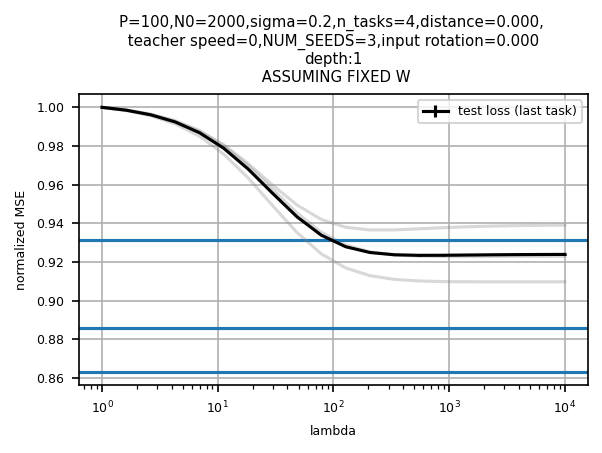

In [40]:

# plt.axhline(seed_avg_last_task_only_test, color='b', label='only learn last task')
# plt.axhline(seed_avg_batch_test, color='r', label='batch')
# plt.axhline(0, color='r', label='batch')
plt.errorbar(lamb_values, adjusted_test_loss[:, :, -1].mean(1), adjusted_test_loss[:, :, -1].var(1), color='k', label='test loss (last task)')

for i in range(NUM_SEEDS):
    plt.plot(lamb_values, adjusted_test_loss[:, i, -1], color='gray', alpha=0.3)
    plt.axhline(adjusted_batch_test[i])

plt.ylabel('normalized MSE')

plt.xlabel('lambda')
plt.xscale('log')
plt.grid()
plt.legend()

plt.title(title_text)
plt.tight_layout()
plt.show()

# colors = np.linspace(0, 1, len(lamb_values))
# task_to_look_at = 1
# plt.figure(figsize=(4, 3))
# for i in range(len(lamb_values)):
#     plt.plot(training_loss_all_tasks[i, 2, task_to_look_at:, task_to_look_at], color=str(colors[i]))

NameError: name 'student_type' is not defined

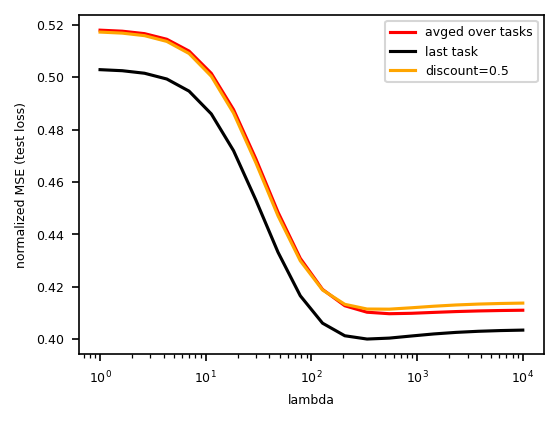

In [5]:
mean_test_loss_all_tasks = test_loss_all_tasks.mean(1)
mean_train_loss_all_tasks = training_loss_all_tasks.mean(1)

discount_factor = 0.5
exponential_scale = discount_factor ** np.arange(n_tasks)[::-1]
exponential_scale /= exponential_scale.sum()

plt.figure(figsize=(4, 3))
# plt.axhline(seed_avg_last_task_only_test, color='b', label='only learn last task')
# plt.axhline(seed_avg_batch_test, color='r', label='batch')
# plt.axhline(0, color='r', label='batch')
plt.plot(lamb_values, mean_test_loss_all_tasks.mean(1), color='r', label='avged over tasks')
plt.plot(lamb_values, mean_test_loss_all_tasks[:, -1], color='k', label='last task')
plt.plot(lamb_values, (mean_test_loss_all_tasks * exponential_scale).sum(-1), color='orange', label=f'discount={discount_factor}')
plt.ylabel('normalized MSE (test loss)')
plt.xscale('log')
plt.legend()
plt.xlabel('lambda')
title_text = f'P={P},N0={N0},sigma={sigma},n_tasks={n_tasks},distance={input_dist:.3f}, \n ' +\
          f'teacher speed={teacher_speed},NUM_SEEDS={NUM_SEEDS},input rotation={input_rotation:.3f} \n' +\
    f'network:{student_type}'
if fixed_w:
    title_text += '\n ASSUMING FIXED W'
plt.title(title_text)

Text(0.5, 1.0, 'colors: cool->warm: first->last task')

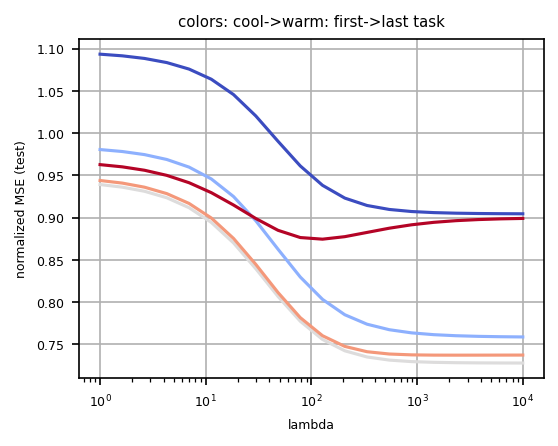

In [36]:
plt.figure(figsize=(4, 3))
colors = plt.cm.coolwarm(np.linspace(0, 1, n_tasks))
for task_ind in range(n_tasks):
    plt.plot(lamb_values, mean_test_loss_all_tasks[:, task_ind], color=colors[task_ind])
plt.xscale('log')
plt.xlabel('lambda'); plt.ylabel('normalized MSE (test)'); plt.grid()
plt.title('colors: cool->warm: first->last task')

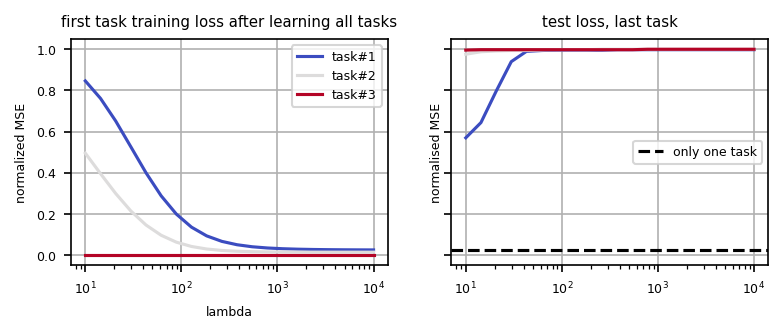

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2), sharey=True)
colors = plt.cm.coolwarm(np.linspace(0, 1, n_tasks))
axes = axes.ravel()
plt.sca(axes[0])
for i in range(n_tasks):
    plt.plot(lamb_values, mean_train_loss_all_tasks[:, -1, i], label=f'task#{i+1}', color=colors[i])
plt.xscale('log')
plt.xlabel('lambda')
plt.ylabel('normalized MSE')
plt.title('first task training loss after learning all tasks')
plt.grid()
plt.legend()



plt.sca(axes[1])
for i in range(n_tasks):fd
    plt.plot(lamb_values, mean_test_loss_all_tasks[:, i], color=colors[i])
plt.axhline(seed_avg_last_task_only_test, color='k', ls='--', label='only one task')
plt.xscale('log')
plt.grid()
plt.ylabel('normalised MSE')
plt.title('test loss, last task')
plt.legend()

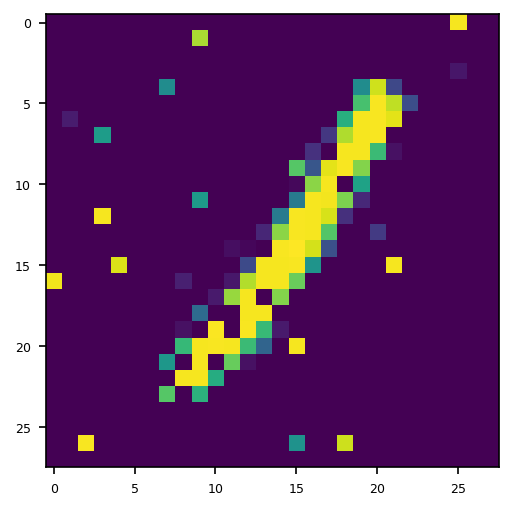

In [13]:
plt.figure()
plt.imshow(train_x[2][0].reshape(28, 28))